# Chatbot local memory

In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI

from typing import TypedDict, Annotated

In [2]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [3]:
def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000
    )

llm = get_groq_llm()

In [4]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
def chat_node(state: ChatState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {'messages': [response]}

In [6]:
graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)
chatbot = graph.compile()


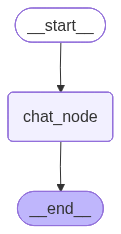

In [7]:
chatbot

In [8]:
initial_state = {
    'messages': [HumanMessage(content="What is the capital of India")]
}

chatbot.invoke(initial_state)

{'messages': [HumanMessage(content='What is the capital of India', additional_kwargs={}, response_metadata={}, id='0d22880e-ad5d-4d77-ab53-54814f4427fd'),
  AIMessage(content='The capital of India is **New\u202fDelhi**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 77, 'total_tokens': 121, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 24, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.049490764, 'prompt_time': 0.004239856, 'completion_time': 0.044335467, 'total_time': 0.048575323}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'id': 'chatcmpl-f9a83bf7-1c1f-4923-847e-c2132135f9db', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e54c9-9ade-7f01-b248-5f28a1e0bf16-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input

In [9]:
initial_state = {
    'messages': [HumanMessage(content='HI there my name is Vignesh, How are you doing today?')]
}

chatbot.invoke(initial_state)

{'messages': [HumanMessage(content='HI there my name is Vignesh, How are you doing today?', additional_kwargs={}, response_metadata={}, id='a7a10f65-7ede-4721-ac02-032a8fc62724'),
  AIMessage(content='Hello Vignesh! I’m just a bundle of code, so I don’t have feelings, but I’m here and ready to help you out. How are you doing today? Anything exciting on your radar?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 86, 'total_tokens': 182, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 44, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.049417092, 'prompt_time': 0.004673527, 'completion_time': 0.098964213, 'total_time': 0.10363774}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c5a89987dc', 'id': 'chatcmpl-3d3c0ad0-25b2-43b1-a8a6-dcc7489b6e6d', 'service_tier': 'on_demand', 'finish_rea

In [10]:
initial_state = {
    'messages': [HumanMessage(content='Hey do you remember my name?')]
}

chatbot.invoke(initial_state)['messages'][-1].content


'I don’t actually have a memory of past interactions, so I don’t know your name yet. What should I call you?'

## Let's Add Memory

In [11]:
from langgraph.checkpoint.memory import InMemorySaver

In [12]:
# graph = StateGraph(ChatState)
# graph.add_node('chat_node', chat_node)
# graph.add_edge(START, 'chat_node')
# graph.add_edge('chat_node', END)

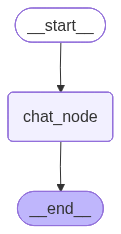

In [13]:
chatbot = graph.compile(checkpointer=InMemorySaver())
chatbot

In [14]:
config = {
    "configurable": {
        'thread_id': '1'
    }
}

In [15]:
initial_state = {
    'messages': [HumanMessage(content='HI there my name is Vignesh')]
}
chatbot.invoke(initial_state, config=config)

{'messages': [HumanMessage(content='HI there my name is Vignesh', additional_kwargs={}, response_metadata={}, id='b5ef5410-a6e8-4a9b-a8f5-264a02390f46'),
  AIMessage(content='Hello Vignesh! 👋 How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 79, 'total_tokens': 166, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 64, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.049716842, 'prompt_time': 0.003838748, 'completion_time': 0.088065837, 'total_time': 0.091904585}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'id': 'chatcmpl-975ed6f9-4e00-4f4a-ac5c-ccd56b9002b2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e54c9-9dac-7c72-ae83-cdee96cd5d18-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input

In [18]:
initial_state = {
    'messages': [HumanMessage(content='Do you remember my name?')]
}

chatbot.invoke(initial_state,config=config)['messages'][-1].content


'I don’t have long‑term memory, so I can’t “remember” things from earlier conversations.\u202fBut in this chat you told me your name is **Vignesh**! How can I help you today?'